# Configurando o Ambiente

**Configuração Modelo do Autor** 
- formula = "group ~ C(Island, Treatment(reference='Gran Canaria')) + C(Breed, Treatment(reference='Crossbreed'))"
- modelo = smf.logit(formula, data=study_filtrado).fit(disp=0)

**Sobre a Fórmula Utilizada:**

Ajuste de Variáveis (Confounding): Ao colocar Island e Breed juntas, o autor isola o efeito da raça. Isso impede que o modelo atribua um risco alto a uma raça apenas porque ela é muito comum em uma ilha que possui fatores ambientais de risco (como poluição ou dieta regional).

Estabelecimento de Baseline: O comando Treatment(reference=...) define que o "Cachorro Zero" do estudo é o Crossbreed (SRD) vivendo em Gran Canaria. Todos os outros resultados são calculados como uma variação (maior ou menor) em relação a esse padrão.

**Desempenho do Modelo do Autor (Baseline)**
- AUC-ROC: 0.789 (Quão bem ele separa doentes de saudáveis)
- Brier Score: 0.025 (Quão bem calibrada é a porcentagem. Mais baixo é melhor)

In [145]:
PALETTE = [
    "midnightblue",
    "navy",
    "darkblue",
    "mediumblue",
    "blue",
    "slateblue",
    "darkslateblue",
    "mediumslateblue",
    "mediumpurple",
    "rebeccapurple",
    "blueviolet",
    "indigo",
    "darkorchid",
    "darkviolet",
    "mediumorchid",
    "thistle",
    "plum",
    "violet",
    "purple",
    "darkmagenta",
    "fuchsia",
    "magenta",
    "orchid"
]

### Analisando Base Utilizada

In [146]:
import pandas as pd
study_filtrado = pd.read_csv('../data/study_filtered.csv')
study_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76117 entries, 0 to 76116
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Breed   76117 non-null  object
 1   Island  76117 non-null  object
 2   group   76117 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [147]:
study_filtrado['group'].value_counts()

group
0    74302
1     1815
Name: count, dtype: int64

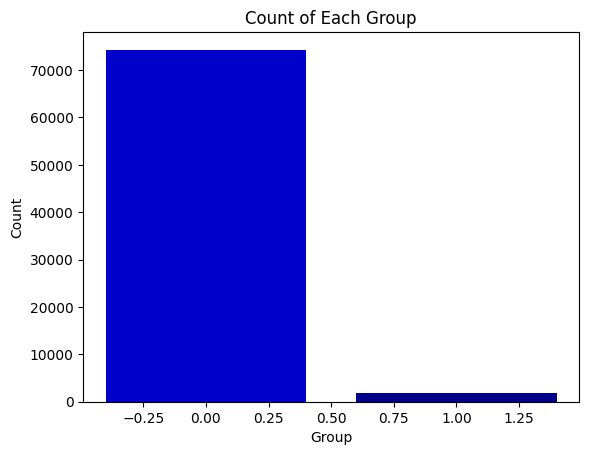

In [148]:
import matplotlib.pyplot as plt

plt.bar(
    study_filtrado['group'].value_counts().index, 
    study_filtrado['group'].value_counts().values, 
    color=[PALETTE[3], PALETTE[2]]
)
plt.xlabel('Group')
plt.ylabel('Count')
plt.title('Count of Each Group')
plt.savefig('../output/Group_Counts.png', dpi=300, bbox_inches='tight')
plt.show()

In [149]:
study_filtrado['Breed'].value_counts()

Breed
Crossbreed                        27258
Canarian Warren Hound             14995
Yorkshire Terrier                  6852
Chihuahua                          3994
French Bulldog                     3167
Labrador Retriever                 1860
English Pointer                    1770
German Shepherd Dog                1608
Canarian Mastiff                   1267
Pit Bull Terrier                   1139
Cocker Spaniel                      972
Poodle                              926
Miniature Pinscher                  900
Staffordshire Bull Terrier          791
Golden Retriever                    752
Bichon frise                        697
Boxer                               683
American Staffordshire Terrier      633
Majorero                            620
Bull Terrier                        564
Shih-Tzu                            449
Jack Russell Terrier                428
Andalusian Ratter                   426
Dalmatian                           410
Beagle                            

### Metodologia

1. Dividir dados em treino e teste 80/20
2. Treinar o modelo com cv de 5 folds
3. testar modelo

- para modelos de arvores serão utilizados random search

# Modelos

## Regressão Classica (sem penalidade)

### Modelo Base Divisão 80/20

In [150]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
import statsmodels.formula.api as smf

def treinar_skf(formula, df_treino, coluna_alvo='group', n_splits=5):
    y_para_corte = df_treino[coluna_alvo]
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    auc_scores = []
    brier_scores = []
        
    for fold, (train_idx, val_idx) in enumerate(skf.split(df_treino, y_para_corte), 1):
        
        df_fold_train = df_treino.iloc[train_idx]
        df_fold_val = df_treino.iloc[val_idx]
        
        modelo_ajustado = smf.logit(formula, data=df_fold_train).fit(disp=0)
        
        probs = modelo_ajustado.predict(df_fold_val)
        y_fold_val = df_fold_val[coluna_alvo]
        
        auc = roc_auc_score(y_fold_val, probs)
        brier = brier_score_loss(y_fold_val, probs)
        
        auc_scores.append(auc)
        brier_scores.append(brier)
        

    print("\n[RESULTADO CV - TREINO] Statsmodels (Baseline):")
    print(f"AUC-ROC Média  : {np.mean(auc_scores):.3f} (+/- {np.std(auc_scores):.3f})")
    print(f"Brier Médio    : {np.mean(brier_scores):.3f} (+/- {np.std(brier_scores):.3f})\n")
    
    return np.mean(auc_scores), np.mean(brier_scores)


In [151]:
from sklearn.model_selection import train_test_split

df_treino, df_teste = train_test_split(
    study_filtrado, 
    test_size=0.2, 
    random_state=42, 
    stratify=study_filtrado['group']
)

In [152]:
formula = "group ~ C(Island, Treatment(reference='Gran Canaria')) + C(Breed, Treatment(reference='Crossbreed'))"
treinar_skf(formula, df_treino, coluna_alvo='group', n_splits=5)


[RESULTADO CV - TREINO] Statsmodels (Baseline):
AUC-ROC Média  : 0.782 (+/- 0.006)
Brier Médio    : 0.023 (+/- 0.000)



(np.float64(0.7818557848120087), np.float64(0.022564811797526348))

In [153]:
modelo_base = smf.logit(formula, data=df_treino).fit(disp=0)


probs_teste = modelo_base.predict(df_teste)
y_gabarito = df_teste['group']

auc_final = roc_auc_score(y_gabarito, probs_teste)
brier_final = brier_score_loss(y_gabarito, probs_teste)

print(f"AUC-ROC Final : {auc_final:.3f}")
print(f"Brier Final   : {brier_final:.3f}")

AUC-ROC Final : 0.784
Brier Final   : 0.023


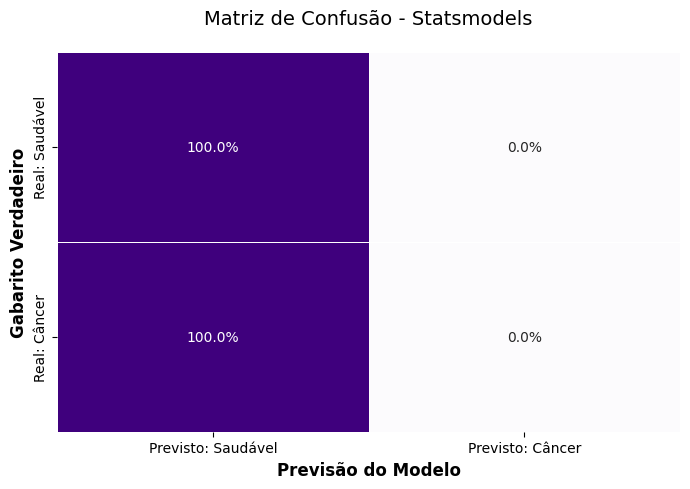

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

limiar = 0.5

previsoes_binarias = (probs_teste >= limiar).astype(int)

cm = confusion_matrix(y_gabarito, previsoes_binarias, normalize='true') 

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap='Purples' ,fmt='.1%',
            linewidths=.5, cbar=False, vmin=0, vmax=1,
            xticklabels=['Previsto: Saudável', 'Previsto: Câncer'],
            yticklabels=['Real: Saudável', 'Real: Câncer'])


plt.title('Matriz de Confusão - Statsmodels', pad=20, fontsize=14)
plt.ylabel('Gabarito Verdadeiro', fontsize=12, fontweight='bold')
plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/Confusion_Matrix_Statsmodels.png', dpi=300, bbox_inches='tight')
plt.show()

### Scikit Learn

#### Parâmetros

- penalty -> penalidade aplicada às variáveis
    - l2 -> Encolhe os pesos de todas as variáveis, mas não zera nenhuma. Ótimo para manter todas as raças no modelo de forma equilibrada.
    - l1 -> Zera os pesos das variáveis que não importam. Perfeito para "limpar" o modelo e manter só as raças cruciais.
    - elasticnet -> Mistura L1 e L2
    - None -> sem penalidade

- C -> É a força inversa da regularização
    - Valores altos: Menos restrição. O modelo confia muito nos dados de treino.
    - Valores baixos: Mais restrição. O modelo fica mais cético, impedindo que raças com poucos casos dominem a probabilidade.

- l1_ratio -> Só é usado se você escolher penalty='elasticnet'. Ele dita a proporção da mistura.
    - Um valor de 0.2 significa 20% Lasso (zerar variáveis) e 80% Ridge (encolher variáveis). Um valor de 0.5 é meio a meio.

- solver -> Define a engrenagem de cálculo.
    - 'lbfgs': Excelente e rápido para a maioria dos casos, mas só suporta penalidade L2 ou None.asd
    - 'liblinear': O melhor para datasets menores e é obrigatório se você quiser usar a penalidade L1 (Lasso).
    - 'saga': O único que suporta Elastic-Net. Também é muito rápido para datasets gigantescos (centenas de milhares de linhas).
    - newton-cholesky: Ele calcula a matriz de curvatura exata e a resolve usando uma técnica de álgebra linear chamada "Decomposição de Cholesky".

- class_weight -> Dá pesos diferentes para acertos e erros dependendo da classe.
    - None: Trata todos os cães com o mesmo peso.
    - 'balanced': O modelo matematicamente aumenta o "peso" do erro quando ele erra um cão com câncer. Ele força o algoritmo a prestar muito mais atenção na minoria doente para equilibrar o jogo.

- max_iter -> O número máximo de tentativas (passos) que o solver tem para achar a matemática perfeita.
    - Se você rodar o modelo e receber um aviso vermelho dizendo "ConvergenceWarning: lbfgs failed to converge", significa que o modelo precisava de mais tempo para pensar. Aumente para 500 ou 1000.


#### Regressão Modelo Puro

In [114]:
from sklearn.model_selection import train_test_split

dados_ml = pd.get_dummies(study_filtrado, columns=['Breed', 'Island'], drop_first=True)

X = dados_ml.drop(columns=['group'])
y = dados_ml['group']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [115]:
from sklearn.metrics import roc_auc_score, brier_score_loss

def avaliar_modelo_cv(modelo, X, y, nome="Modelo ML", n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    auc_scores = []
    brier_scores = []
    
    print(f"Iniciando Validação Cruzada ({n_splits} folds) para: {nome}...")
    
    for fold, (train_index, val_index) in enumerate(skf.split(X, y), 1):
        
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
        
        modelo.fit(X_train_fold, y_train_fold)
        
        probs = modelo.predict_proba(X_val_fold)[:, 1]
        
        auc = roc_auc_score(y_val_fold, probs)
        brier = brier_score_loss(y_val_fold, probs)
        
        auc_scores.append(auc)
        brier_scores.append(brier)
        
    auc_media = np.mean(auc_scores)
    auc_std = np.std(auc_scores)
    
    brier_media = np.mean(brier_scores)
    brier_std = np.std(brier_scores)
    
    print(f"\n[RESULTADO CV - TREINO] {nome}:")
    print(f"AUC-ROC Média  : {auc_media:.3f} (+/- {auc_std:.3f})")
    print(f"Brier Médio    : {brier_media:.3f} (+/- {brier_std:.3f})\n")
    
    return auc_media, brier_media

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
import pandas as pd


modelo_lr_base = LogisticRegression(class_weight='balanced', random_state=42)


auc_cv_ml, brier_cv_ml = avaliar_modelo_cv(
    modelo=modelo_lr_base, 
    X=X_train, 
    y=y_train, 
    nome="Regressão Logística (Sklearn)"
)


modelo_oficial_lr = LogisticRegression(class_weight='balanced', random_state=42)
modelo_oficial_lr.fit(X_train, y_train)

probs_teste_ml = modelo_oficial_lr.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

classes_previstas_ml = (probs_teste_ml >= 0.5).astype(int)

Iniciando Validação Cruzada (5 folds) para: Regressão Logística (Sklearn)...

[RESULTADO CV - TREINO] Regressão Logística (Sklearn):
AUC-ROC Média  : 0.782 (+/- 0.007)
Brier Médio    : 0.197 (+/- 0.001)

AUC-ROC Final : 0.785
Brier Final   : 0.199



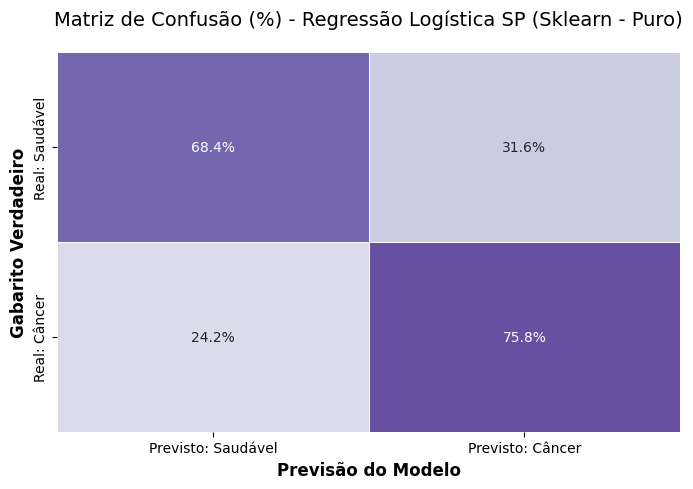

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def matriz_confusao_LR(y_test, y_pred, modelo):
    cm_percent = confusion_matrix(y_test, y_pred, normalize='true')

    plt.figure(figsize=(7, 5))
    
    # 2. Mudamos o fmt para '.1%' para exibir 85.5% em vez de decimais puros
    sns.heatmap(cm_percent, annot=True, fmt='.1%', cmap='Purples', 
                linewidths=.5, cbar=False, vmin=0, vmax=1,
                xticklabels=['Previsto: Saudável', 'Previsto: Câncer'],
                yticklabels=['Real: Saudável', 'Real: Câncer'])

    plt.title(f'Matriz de Confusão (%) - {modelo}', pad=20, fontsize=14)
    plt.ylabel('Gabarito Verdadeiro', fontsize=12, fontweight='bold')
    plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../output/Confusion_Matrix_Norm_{modelo.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Como chamar a função:
matriz_confusao_LR(y_test, classes_previstas_ml, modelo="Regressão Logística SP (Sklearn - Puro)")

#### Hiperparâmetros

In [119]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'solver': ['lbfgs', 'newton-cg'],
}

modelo = LogisticRegression(random_state=42, penalty=None, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=modelo, 
    param_grid=param_grid,
    scoring='roc_auc', 
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("\n--- RESULTADOS DO GRID SEARCH SEM PENALIDADE ---")
print(f"Melhor nota AUC-ROC durante o treino: {grid_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

melhor_modelo_sp = grid_search.best_estimator_


--- RESULTADOS DO GRID SEARCH SEM PENALIDADE ---
Melhor nota AUC-ROC durante o treino: 0.782
Melhores parâmetros encontrados:
{'solver': 'newton-cg'}


In [120]:
probs_teste_ml = melhor_modelo_sp.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

AUC-ROC Final : 0.785
Brier Final   : 0.199



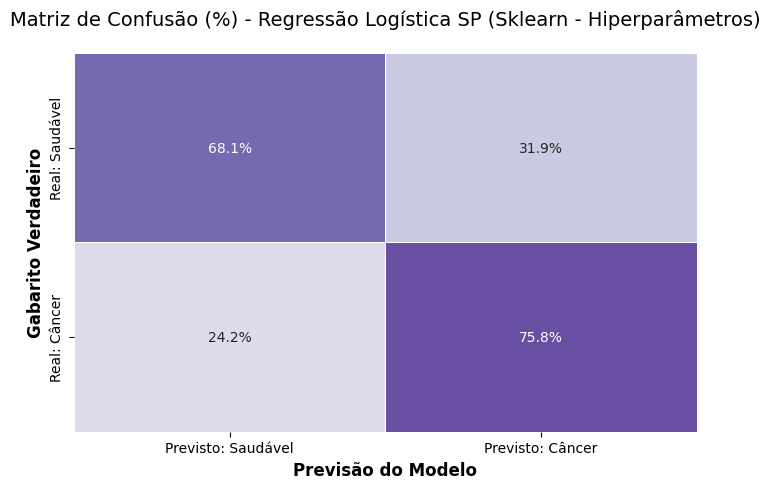

In [121]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Regressão Logística SP (Sklearn - Hiperparâmetros)")

## Regressão Logistica ML (com penalidade)

#### Modelo Puro

In [122]:
modelo = LogisticRegression(random_state=42, class_weight='balanced')
avaliar_modelo_cv(modelo, X_test, y_test, "Logistic Regression Modelo Puro (Scikit-learn)")

Iniciando Validação Cruzada (5 folds) para: Logistic Regression Modelo Puro (Scikit-learn)...

[RESULTADO CV - TREINO] Logistic Regression Modelo Puro (Scikit-learn):
AUC-ROC Média  : 0.763 (+/- 0.011)
Brier Médio    : 0.195 (+/- 0.006)



(np.float64(0.763267254185862), np.float64(0.1947433140904559))

In [123]:
probs_teste_ml = modelo.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

AUC-ROC Final : 0.797
Brier Final   : 0.193



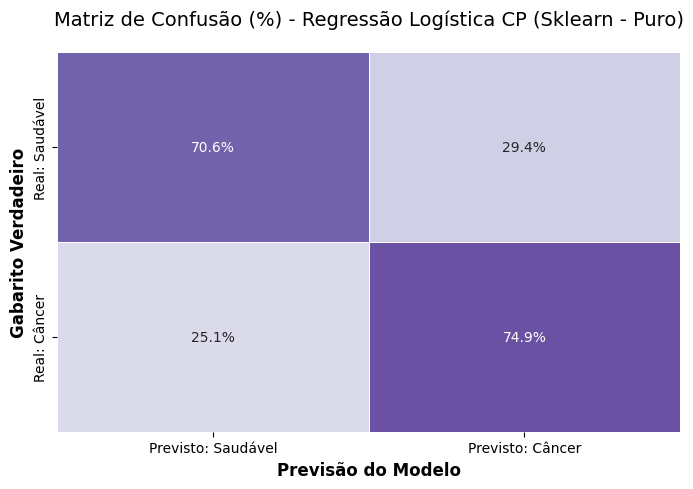

In [124]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Regressão Logística CP (Sklearn - Puro)")

#### Hiperparametrização

In [125]:
param_grid = {
    'C':  [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'solver': ['newton-cg', 'liblinear', 'lbfgs'],
}

modelo = LogisticRegression(random_state=42, class_weight='balanced', penalty='l2')

grid_search = GridSearchCV(
    estimator=modelo, 
    param_grid=param_grid,
    scoring='roc_auc', 
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("\n--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---")
print(f"Melhor nota AUC-ROC durante o treino: {grid_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

melhor_modelo = grid_search.best_estimator_


--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---
Melhor nota AUC-ROC durante o treino: 0.782
Melhores parâmetros encontrados:
{'C': 0.1, 'solver': 'liblinear'}


In [126]:
probs_teste_ml = melhor_modelo.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

AUC-ROC Final : 0.784
Brier Final   : 0.199



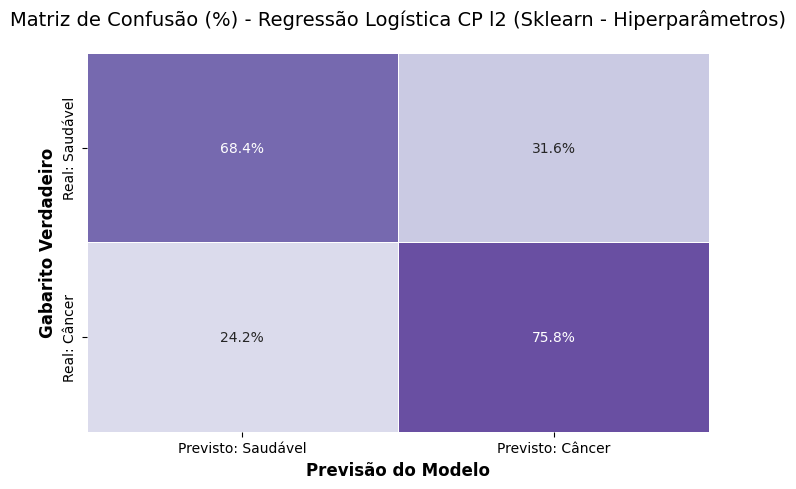

In [127]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Regressão Logística CP l2 (Sklearn - Hiperparâmetros)")

In [128]:
param_grid = {
    'C':  [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'solver': ['liblinear'],
}

modelo = LogisticRegression(random_state=42, class_weight='balanced', penalty='l1')

grid_search = GridSearchCV(
    estimator=modelo, 
    param_grid=param_grid,
    scoring='roc_auc', 
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("\n--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---")
print(f"Melhor nota AUC-ROC durante o treino: {grid_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

melhor_modelo = grid_search.best_estimator_


--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---
Melhor nota AUC-ROC durante o treino: 0.782
Melhores parâmetros encontrados:
{'C': 0.5, 'solver': 'liblinear'}


In [129]:
probs_teste_ml = melhor_modelo.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

AUC-ROC Final : 0.785
Brier Final   : 0.199



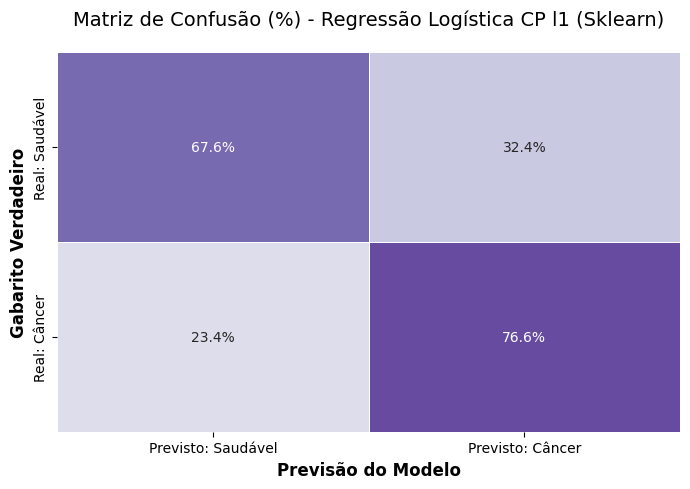

In [130]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Regressão Logística CP l1 (Sklearn)")

## Modelos de Árvores

### Random Forest

#### Parâmetros

- n_estimators -> número de árvores (quantidade de decisores)
    - Geralmente, quanto mais, melhor a performance e mais estável é o modelo. No entanto, o custo computacional aumenta (demora mais para treinar). Chega um ponto em que adicionar mais árvores não melhora o modelo (retorno decrescente).

- max_depth -> A profundidade máxima da árvore (tomar cuidado com overfiting)
    - Controla o número máximo de "níveis" ou perguntas que a árvore pode fazer antes de dar uma resposta. Se for None, a árvore cresce até que todas as folhas sejam "puras" (contenham apenas uma classe).

- min_samples_split -> O número mínimo de amostras necessárias para dividir um nó interno.
    - Se um nó tem 5 amostras e você definiu esse valor como 10, a árvore para de dividir ali, mesmo que ainda não seja uma folha pura. Aumentar esse valor (ex: 5, 10, 20) força a árvore a ser mais generalista e menos sensível a pequenos ruídos nos dados.

- min_samples_leaf -> O número mínimo de amostras que uma folha (o nó final que dá a decisão) deve ter.
    - Semelhante ao min_samples_split, mas foca no final da árvore. Se uma divisão fosse criar uma folha com apenas 1 amostra, a divisão não acontece. Aumentar esse valor (ex: 2, 5, 10) também previne overfitting, suavizando o modelo.

- max_leaf_nodes -> O número máximo de folhas que a árvore pode ter.
    - É uma forma alternativa de limitar o crescimento, focando no número total de resultados possíveis por árvore.

- max_features -> O número máximo de características (features) que o modelo pode considerar ao procurar a melhor divisão em cada nó.
    - 'sqrt': Usa a raiz quadrada do número total de features (o padrão e geralmente o melhor para classificação).
    - 'log2': Usa o logaritmo na base 2.
    - None: Usa todas as features (nesse caso, vira uma técnica chamada Bagging e perde um pouco da vantagem do Random Forest).

- bootstrap -> Se as amostras são retiradas com reposição (Bootstrap) ao construir as árvores.
    - Em vez de treinar cada árvore com os mesmos 100% dos dados, cada árvore recebe um subconjunto aleatório (com o mesmo tamanho do original, mas algumas linhas são repetidas e outras ignoradas). Isso é fundamental para a diversidade das árvores.

- max_samples (Padrão = None) -> (Usado apenas se bootstrap=True). A porcentagem máxima de amostras a ser usada para treinar cada árvore. Se você tiver 1 milhão de linhas, pode querer que cada árvore use apenas 50% delas para treinar mais rápido, sem perder a diversidade.

- class_weigt -> peso das classes


#### Referências

Definir um espaço de busca focado
Em bases com muitas linhas e poucas features, é comum restringir o tuning a:

- n_estimators: variar em uma faixa de valores médios/altos até o ganho marginal desaparecer.

- max_features: testar valores padrão (por exemplo, sqrt(p)) e usar todas as features.

- min_samples_leaf e min_samples_split: aumentar levemente em relação ao padrão para evitar folhas extremamente pequenas em dados numerosos.

- class_weight: comparar None, 'balanced' e alguns conjuntos de pesos manuais para a classe minoritária, ou utilizar uma implementação de Balanced Random Forest.

https://www.mdpi.com/2076-3417/12/14/7253 -> base
- XG boost
    - parameter   Search Type     Search Space Range
    - gamma	continuous	[5.0, 11.0]
    - learning rate	continuous	[0.07, 0.6]
    - n estimators	discrete	50, 100, 150
    - regulation alpha	discrete	1 × 10^−5, 1 × 10^−2 ,0.75
    - regulation lambda	discrete	1 × 10^−5, 1 × 10^−2 ,0.45
    - min child weight	discrete	1.5, 6, 10
    - subsample	discrete	0.6, 0.95
    - max depth	discrete	3, 6, 9

- RF
    - parameter   Search Type     Search Space Range
    - n estimators	discrete	100, 200, 500
    - max depth	discrete	4, 5, 6, ..., 11
    - min samples	discrete	2, 3, 4, 5
    - min samples leaf	discrete	1, 3, 5, 7

#### Modelo Puro

In [131]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_base.fit(X_train, y_train)
avaliar_modelo_cv(rf_base, X_train, y_train, "Random Forest Modelo Puro (Scikit-learn)")

Iniciando Validação Cruzada (5 folds) para: Random Forest Modelo Puro (Scikit-learn)...

[RESULTADO CV - TREINO] Random Forest Modelo Puro (Scikit-learn):
AUC-ROC Média  : 0.771 (+/- 0.004)
Brier Médio    : 0.187 (+/- 0.001)



(np.float64(0.7710425237303736), np.float64(0.1867401080381236))

In [132]:
probs_teste_ml = rf_base.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

AUC-ROC Final : 0.777
Brier Final   : 0.188



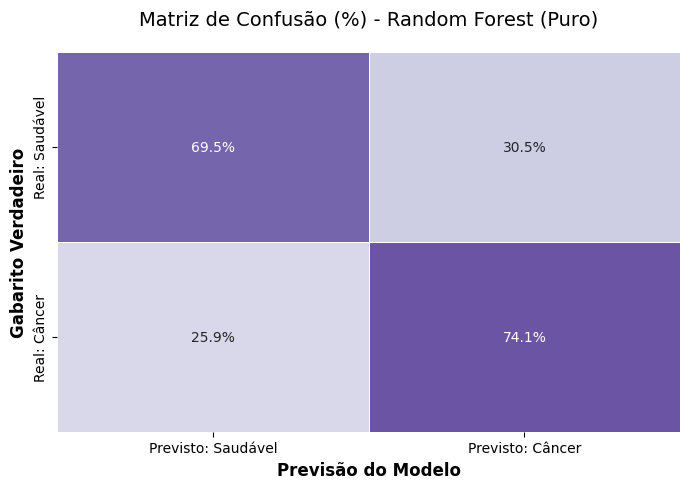

In [133]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Random Forest (Puro)")

#### Hiperparametrizado

In [49]:
#! NEED DO DO

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint 


param_dist = {
    'n_estimators': randint(10, 1000),         
    'max_depth': randint(3, 20),  
    'min_samples_split': randint(2, 20),     
    'min_samples_leaf': randint(1, 20)      
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
random_search = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=300, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1,
    random_state=42, 
)
random_search.fit(X_train, y_train)


print("\n--- RESULTADOS DO RANDOM SEARCH ---")
print(f"Melhor nota AUC-ROC durante o treino: {random_search.best_score_:.3f}")
print("Melhores parâmetros sorteados e encontrados:")
print(random_search.best_params_)

melhor_rf_random = random_search.best_estimator_

In [ ]:
probs_teste_ml = melhor_rf_random.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=11413460

http://join.if.uinsgd.ac.id/index.php/join/article/view/1590/364

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform, loguniform

contagem_classes = y_train.value_counts()
peso_positivo = contagem_classes[0] / contagem_classes[1] 
print(f"O scale_pos_weight calculado foi: {peso_positivo:.2f}\n")

param_dist = {
    'n_estimators': randint(50, 1000),         
    'max_depth': randint(3, 20),               
    'learning_rate': loguniform(0.005, 0.3),   
    'gamma': uniform(loc=5.0, scale=6.0),      
    'min_child_weight': randint(1, 15),        
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],    
    'reg_alpha': uniform(0.0, 5.0),            
    'reg_lambda': uniform(1.0, 5.0)            
}

xgb_base = XGBClassifier(
    random_state=42, 
    scale_pos_weight=peso_positivo,
    eval_metric='auc', 
    use_label_encoder=False 
)

random_search = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=param_dist, 
    n_iter=300, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
    random_state=42,
)

random_search.fit(X_train, y_train)

print("\n--- RESULTADOS DO RANDOM SEARCH (XGBOOST) ---")
print(f"Melhor nota AUC-ROC durante o treino (CV): {random_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
for param, valor in random_search.best_params_.items():
    if isinstance(valor, float):
        print(f"  {param}: {valor:.3f}")
    else:
        print(f"  {param}: {valor}")

melhor_xgb_random = random_search.best_estimator_

In [ ]:
probs_teste_ml = melhor_xgb_random.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")